In [16]:
import pandas as pd
import pyfpgrowth
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 200) 

In [4]:
# Get the qualifications and the sector is under
qual_sector_df = pd.read_csv('programs.csv')
qual_sector_map = dict(zip(qual_sector_df.Qualification, qual_sector_df.SECTOR))

In [5]:
# get the leads
leads_df = pd.read_csv('Upload_ Leads PHP(TESDA).csv', encoding = "ISO-8859-1")
priority_lead_df = leads_df[leads_df['Priority Level'] == '1st Priority']

# priority mapping
priority_map = dict(zip(leads_df.Company, leads_df['Priority Level']))

# get the name of the companies
priority_companies = priority_lead_df['Company'].dropna()
lead_companies = leads_df['Company'].dropna()

programs_df = pd.read_csv('filter_TVET_EDA_NCR_4A(Clean Data).csv', encoding = "ISO-8859-1")
lead_programs_df = programs_df[programs_df['Institution Name'].isin(lead_companies)].copy()

lead_programs_df = lead_programs_df[['Institution Name', 'Qualification']].copy()
lead_programs_df['Sector'] = lead_programs_df['Qualification'].map(qual_sector_map)

# Initialize
insti_qual = {}
insti_sector = {}
priority_insti_qual = {}
priority_insti_sector = {}

priority_set = set(priority_companies)

for _, row in lead_programs_df.iterrows():
    institution = row['Institution Name']
    qualification = row['Qualification']

    # Get sector safely
    sector = qual_sector_map[qualification]

    # All institutions
    insti_qual.setdefault(institution, []).append(qualification)
    if sector:
        insti_sector.setdefault(institution, []).append(sector)

    # Priority institutions
    if institution in priority_set:
        priority_insti_qual.setdefault(institution, []).append(qualification)
        if sector:
            priority_insti_sector.setdefault(institution, []).append(sector)

# Common Combinations of Qualifications

In [6]:
# OVERALL
qual_offered = list(insti_qual.values())
patterns = pyfpgrowth.find_frequent_patterns(qual_offered, 3)
itemset_freq = pd.DataFrame({
    'itemset': list(patterns.keys()),
    'count': list(patterns.values())
})
itemset_freq['support'] = itemset_freq['count'] / len(insti_qual.keys())

# PRIORITY
priority_qual_offered = list(priority_insti_qual.values())
patterns = pyfpgrowth.find_frequent_patterns(priority_qual_offered, 3)
priority_itemset_freq = pd.DataFrame({
    'itemset': list(patterns.keys()),
    'count': list(patterns.values())
})
priority_itemset_freq['support'] = priority_itemset_freq['count'] / len(priority_insti_qual.keys())

In [37]:
priority_itemset_freq.sort_values('count', ascending=False).head(10)

,itemset,count,support
272,"(Bread and Pastry Production NC II,)",15,0.652174
270,"(Housekeeping NC II,)",13,0.565217
271,"(Bread and Pastry Production NC II, Housekeeping NC II)",10,0.434783
268,"(Bread and Pastry Production NC II, Food and Beverage Services NC II)",10,0.434783
267,"(Food and Beverage Services NC II, Housekeeping NC II)",10,0.434783
269,"(Bread and Pastry Production NC II, Food and Beverage Services NC II, Housekeeping NC II)",8,0.347826
266,"(Bread and Pastry Production NC II, Cookery NC II)",8,0.347826
253,"(Bartending NC II, Food and Beverage Services NC II)",8,0.347826
211,"(Hilot (Wellness Massage) NC II,)",7,0.304348
248,"(Bartending NC II, Food and Beverage Services NC II, Housekeeping NC II)",7,0.304348


In [49]:
priority_qual_offered = list(priority_insti_qual.values())
priority_qual_offered_w_o_bread = [
    [qual for qual in sublist if qual != "Bread and Pastry Production NC II"]
    for sublist in priority_qual_offered
]
patterns = pyfpgrowth.find_frequent_patterns(priority_qual_offered_w_o_bread, 3)
priority_itemset_freq = pd.DataFrame({
    'itemset': list(patterns.keys()),
    'count': list(patterns.values())
})
priority_itemset_freq['support'] = priority_itemset_freq['count'] / len(priority_insti_qual.keys())
priority_itemset_freq.sort_values('count', ascending=False).head(10)

,itemset,count,support
173,"(Housekeeping NC II,)",13,0.565217
171,"(Food and Beverage Services NC II,)",12,0.521739
172,"(Food and Beverage Services NC II, Housekeeping NC II)",10,0.434783
164,"(Trainers Methodology Level I,)",9,0.391304
163,"(Bartending NC II, Food and Beverage Services NC II)",8,0.347826
170,"(Cookery NC II, Food and Beverage Services NC II)",7,0.304348
140,"(Hilot (Wellness Massage) NC II,)",7,0.304348
162,"(Bartending NC II, Food and Beverage Services NC II, Housekeeping NC II)",7,0.304348
161,"(Bartending NC II, Housekeeping NC II)",7,0.304348
168,"(Cookery NC II, Housekeeping NC II)",6,0.260870


# Visualizing the Schools

In [52]:
insti_qual_df = pd.DataFrame({
    'Institution':priority_insti_qual.keys(),
    'Qualifications':[set(quals) for quals in priority_insti_qual.values()],
})

insti_qual_df['Priority'] = insti_qual_df.Institution.map(priority_map)
insti_qual_df.head()

,Institution,Qualifications,Priority
0,TECHVOC SKILLS INC.,"{Plumbing NC II, Tile Setting NC II, Contact Center Services NC II, Hilot (Wellness Massage) NC II}",1st Priority
1,"UNO CAREGIVER AND DOMESTIC MNGT TRAINING, INC.","{Caregiving (Elderly) NC II, Health Care Services NC II, Caregiving NC II, Housekeeping NC III, Food and Beverage Services NC II, Trainers Methodology Level I, Bartending NC II, Barista NC II, Events Management Services NC III, Food and Beverage Services NC III, Bread and Pastry Production NC II, Domestic Work NC II, Housekeeping NC II}",1st Priority
2,Colegio de Santo Cristo De Burgos Corporation,"{Food and Beverage Services NC II, Trainers Methodology Level I, Driving NC II, Bread and Pastry Production NC II, Housekeeping NC II}",1st Priority
3,MECHATRONICS TECHNOLOGIES CORP.,"{Mechatronics Servicing NC II, Electrical Installation and Maintenance NC III, Mechatronics Servicing NC IV, PV Systems Installation NC II, Instrumentation and Control Servicing NC II, Mechatronics Servicing NC III, RAC Servicing (DomRAC) NC II, Electrical Installation and Maintenance NC II, Electrical Installation and Maintenance NC IV}",1st Priority
4,PSAA INTERNATIONAL ACADEMY INC.,"{Front Office Services NC II, Bookkeeping NC III, Travel Services NC II, Caregiving (Elderly) NC II, Health Care Services NC II, Caregiving NC II, Food and Beverage Services NC II, Trainers Methodology Level I, Cookery NC II, Bartending NC II, Tourism Promotion Services NC II, Events Management Services NC III, Barista NC II, Bread and Pastry Production NC II, Domestic Work NC II, Housekeeping NC II}",1st Priority


In [72]:
cleaned_quals = [set(quals) for quals in priority_insti_qual.values()]

insti_sector_df = pd.DataFrame({
    'Institution': list(priority_insti_sector.keys()),
    'Sectors': [
        list({qual_sector_map[q] for q in quals})
        for quals in cleaned_quals
    ],
})

insti_sector_df['Priority'] = insti_sector_df.Institution.map(priority_map)

insti_sector_df['Specialized Sector'] = insti_sector_df.Sectors.apply(
    lambda lst : max(set(lst), key=lst.count)
)

insti_sector_df.value_counts(['Specialized Sector'], normalize=True)


Specialized Sector                                      
TOURISM SECTOR                                              0.565217
AUTOMOTIVE AND LAND TRANSPORT SECTOR                        0.217391
ELECTRICAL & ELECTRONICS SECTOR                             0.086957
CONSTRUCTION SECTOR                                         0.043478
HEATING, VENTILATION, AIR CONDITIONING AND REFRIGERATION    0.043478
METALS AND ENGINEERING SECTOR                               0.043478
Name: proportion, dtype: float64

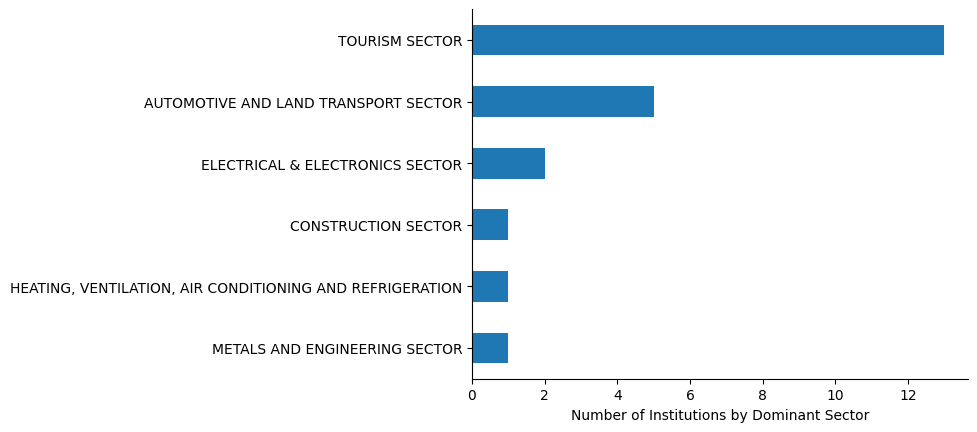

In [79]:
insti_sector_df.value_counts('Specialized Sector')[::-1].plot(kind='barh')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.ylabel('')
plt.xlabel('Number of Institutions by Dominant Sector');